In [25]:
from src.dataset import (
    S7DatasetDiceDetection,
    get_image_detection_datas
)

from src.task.dice_detection.inference import DiceDetectionInference
from src.parse.config import load_config

In [26]:
config = load_config("config/config.yml")

In [27]:
dice_detection_inference = DiceDetectionInference(
    model_path=config.tasks.dice_detection.inference_path,
    image_resolution=config.tasks.dice_detection.image_resolution,
    colored=config.colored
)

## Test Dice Detection Model

In [28]:
# Visualize detection model predictions with bounding boxes
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Recreate generator for visualization
DATASET_PATH = config.dataset_path
image_datas = get_image_detection_datas(DATASET_PATH, 8)
dice_detection_dataset = S7DatasetDiceDetection(
    image_datas=image_datas,
    image_resolution=config.tasks.dice_detection.image_resolution,
    colored=config.colored
)

def generate_dice_detection():
    for img, lbl in dice_detection_dataset:
        yield img, lbl
        
dice_detection_generator = generate_dice_detection()

0.04
0.06
0.07
0.04


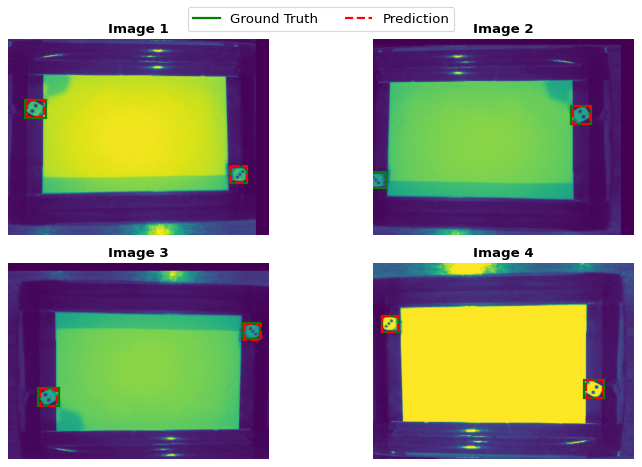

In [29]:
import time

# Determine number of images to display (up to 8)
num_viz_images = 4

# Create figure
rows = 2
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(10, 6), dpi=80)
axes = axes.flatten()

for i in range(num_viz_images):
    ax = axes[i]

    # Get next image and bboxes from generator
    img, bboxes = next(dice_detection_generator)
    ax.imshow(img)

    # Draw ground truth bounding boxes in green
    for bbox in bboxes:
        x, y, w, h = bbox
        rect = Rectangle(
            (x, y),
            w, h,
            linewidth=2,
            edgecolor="green",
            facecolor="none",
            label="Ground Truth",
        )
        ax.add_patch(rect)

    start = time.time()
    boxes = dice_detection_inference(img)
    end = time.time()
    print(f"{end - start:.2f}")
    for box in boxes:
        x, y, w, h = box
        rect = Rectangle((x, y), w, h,
                       linewidth=2, edgecolor='red',
                       facecolor='none', linestyle='--')
        ax.add_patch(rect)

    ax.set_title(f'Image {i+1}', fontsize=12, fontweight='bold')
    ax.axis('off')

# Hide unused subplots
for i in range(num_viz_images, rows * cols):
    axes[i].axis('off')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linewidth=2, label='Ground Truth'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Prediction')
]
fig.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()